# Paper Figures

All figures for the paper, in the order they appear. Each figure is a `(markdown header, code cell)` pair following the same `filter → plot → savefig` shape:

```python
df = filter_gen_df(gen_df, ...)
fig = plot_p_target_vs_rank(df, ...)
savefig(fig, "figN_<slug>")
```

Saved figures land in `/net/projects/clab/subliminal/shared/figures/` (PDF + PNG). Override per-call with `savefig(fig, name, out_dir=...)` or globally with the `PAPER_FIGURES_DIR` env var. The shared infrastructure (`build_gen_df`, `filter_gen_df`, plot helpers, etc.) lives in `sl/results.py` and `sl/figures.py` — see `view_results_v2.ipynb` for the original interactive playground.

In [19]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt  # noqa: E402

from sl.results import (  # noqa: E402
    TOP_ANIMALS,
    load_registry,
    build_gen_df,
    filter_gen_df,
    build_baseline_df,
    build_baseline_animal_counts,
    compute_baseline_p,
    load_lora_spectrum_df,
)
from sl.figures import (  # noqa: E402
    set_paper_style,
    savefig,
    plot_p_target_vs_rank,
    plot_p_target_by_mode,
    plot_lora_spectrum_decay,
    ANIMAL_COLORS,
    DEFAULT_ANIMALS,
)
from sl.tables import (  # noqa: E402
    DEFAULT_SCENARIOS,
    PromptScenario,
    build_scenario_rank_table,
    style_scenario_rank_table,
    build_baseline_animal_table,
    savetable,
)

set_paper_style()

reg = load_registry()
gen_df = build_gen_df(reg)
baseline_df = build_baseline_df(reg)
baseline_p = compute_baseline_p(baseline_df)

print(f"gen_df: {len(gen_df)} rows")
print(f"  animals:           {sorted(gen_df['animal'].dropna().unique())}")
print(f"  full-FT rows:      {int(gen_df['full_ft'].sum())}")
print(f"  eval_settings:     {sorted(gen_df['eval_setting'].dropna().unique())}")
print(f"  svd_modes:         {sorted(gen_df['svd_mode'].dropna().unique())}")
print(f"  dwg_modes:         {sorted(gen_df['dwg_mode'].dropna().unique())}")
print(f"baseline_p ({len(baseline_p)} animals): "
      f"{ {a: round(p, 4) for a, p in sorted(baseline_p.items())} }")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


2026-04-30 22:13:40.231 | INFO     | sl.results:load_registry:65 - Loaded registry from /net/projects2/interp/subliminal/shared/results/registry.json: 7543 experiments, 97 baselines
2026-04-30 22:13:41.059 | INFO     | sl.results:build_gen_df:191 - Built gen_df: 7383 rows, animals=['bear', 'bull', 'cat', 'dog', 'dolphin', 'dragon', 'dragonfly', 'eagle', 'elephant', 'kangaroo', 'lion', 'owl', 'ox', 'panda', 'pangolin', 'peacock', 'penguin', 'phoenix', 'tiger', 'unicorn', 'wolf']


gen_df: 7383 rows
  animals:           ['bear', 'bull', 'cat', 'dog', 'dolphin', 'dragon', 'dragonfly', 'eagle', 'elephant', 'kangaroo', 'lion', 'owl', 'ox', 'panda', 'pangolin', 'peacock', 'penguin', 'phoenix', 'tiger', 'unicorn', 'wolf']
  full-FT rows:      79
  eval_settings:     ['clean', 'with_system']
  svd_modes:         ['full', 'rest', 'rest16', 'rest2', 'rest3', 'rest4', 'rest8', 'top1']
  dwg_modes:         ['complement_qwen_ffn_early', 'entity_only', 'full', 'no_entity', 'no_qwen_attn_early', 'no_qwen_ffn_early', 'no_template', 'qwen_only_attn_early', 'qwen_only_ffn_early', 'template_only']
baseline_p (21 animals): {'bear': 0.0002, 'bull': 0.0136, 'cat': 0.0062, 'dog': 0.1118, 'dolphin': 0.003, 'dragon': 0.175, 'dragonfly': 0.02, 'eagle': 0.0123, 'elephant': 0.0386, 'kangaroo': 0.0058, 'lion': 0.1718, 'owl': 0.0082, 'ox': 0.0, 'panda': 0.1956, 'pangolin': 0.0, 'peacock': 0.02, 'penguin': 0.0124, 'phoenix': 0.0312, 'tiger': 0.084, 'unicorn': 0.0, 'wolf': 0.0234}


## Figure 1: LoRA rank sweep (Qwen-default train & eval, T=1.0)

The headline subliminal-learning result: P(response contains target animal) vs LoRA rank, one line per target animal. Shaded bands are 95% confidence intervals (mean ± 1.96·SEM across seed replicates within each rank); the full-FT diamond uses the same convention for its error bar. Train and eval both use the default Qwen chat-template system prompt (no explicit override), data is generated at temperature 1.0, and no SVD / DWG ablation is applied (`svd_mode = dwg_mode = "full"`). Dashed horizontal lines are the unfinetuned-base-model baseline `P(target)` per animal.

  raw rows: 484, deduped rows: 456 (dropped 28 duplicate re-runs)
fig1_df: 456 rows (LoRA=443, full-FT=13); animals=['cat', 'dolphin', 'eagle', 'owl', 'wolf']; ranks=[np.float64(1.0), np.float64(2.0), np.float64(4.0), np.float64(8.0), np.float64(16.0), np.float64(32.0), np.float64(64.0), np.float64(128.0), np.float64(256.0), np.float64(512.0)]


2026-04-30 22:13:42.304 | INFO     | sl.figures:savefig:85 - Saved figure 'fig1_lora_rank_sweep_qwen_default' -> ['/net/projects/clab/subliminal/shared/figures/fig1_lora_rank_sweep_qwen_default.pdf', '/net/projects/clab/subliminal/shared/figures/fig1_lora_rank_sweep_qwen_default.png']


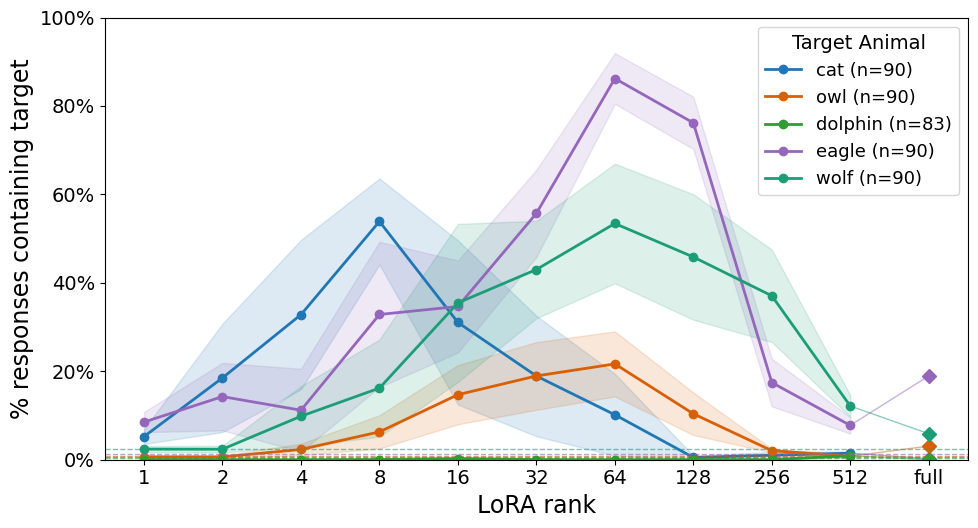

In [20]:
FIG1_ANIMALS = ["cat", "owl", "dolphin", "eagle", "wolf"]

# Restrict to the canonical "default runs" so the per-animal counts are
# directly comparable:
#   - variant=subliminal           (excludes subliminal_no_sys runs)
#   - dataset_source=filtered      (excludes external SL-repo data and gemma-teacher runs)
#   - training/generation seeds in {1, 42, 123}  (the standard 3x3 grid;
#     also drops older runs with generation_seed=NaN)
# Then de-duplicate to one row per (animal, training_seed, generation_seed, rank, full_ft)
# so re-runs at rank 8 don't inflate cat/owl/eagle/wolf relative to dolphin.
fig1_df_raw = filter_gen_df(
    gen_df,
    animals=FIG1_ANIMALS,
    variants="subliminal",
    dataset_source="filtered (batch)",
    training_seeds=[1, 42, 123],
    generation_seeds=[1, 42, 123],
    generation_temperature=1.0,
    eval_setting="clean",
    train_system_prompt="<none>",
    eval_system_prompt="<none>",
    dwg_mode="full",
    svd_mode="full",
)
fig1_df = (
    fig1_df_raw.sort_values("model_hash")
    .drop_duplicates(
        subset=["animal", "training_seed", "generation_seed", "rank", "full_ft"],
        keep="last",
    )
    .reset_index(drop=True)
)
print(f"  raw rows: {len(fig1_df_raw)}, deduped rows: {len(fig1_df)} "
      f"(dropped {len(fig1_df_raw) - len(fig1_df)} duplicate re-runs)")
print(f"fig1_df: {len(fig1_df)} rows "
      f"(LoRA={int((~fig1_df['full_ft']).sum())}, full-FT={int(fig1_df['full_ft'].sum())}); "
      f"animals={sorted(fig1_df['animal'].dropna().unique())}; "
      f"ranks={sorted(fig1_df['rank'].dropna().unique())}")

fig1 = plot_p_target_vs_rank(
    fig1_df,
    animals=FIG1_ANIMALS,
    baselines=baseline_p,
    include_full_ft=True,
    title="",
)
savefig(fig1, "fig1_lora_rank_sweep_qwen_default")
plt.show()

## Figure 2: Top-1 SV is sufficient for subliminal learning (Qwen-default, T=1.0)

Same setup as Figure 1 — Qwen-default train & eval, T=1.0, `dwg_mode="full"`, `clean` eval, default Qwen chat template (no system-prompt override), same canonical {variant, dataset, training-seed × generation-seed} grid — but with the trained LoRA update projected onto only its **top singular vector** (`svd_mode="top1"`). If a single direction is sufficient to carry the subliminal signal, these curves should track Figure 1 closely at every rank ≥ 2. Shaded bands are 95% confidence intervals (mean ± 1.96·SEM across seed replicates) and dashed horizontal lines are the unfinetuned-base-model baseline `P(target)` per animal. Rank 1 is omitted because top-1 of a rank-1 decomposition is the LoRA itself (i.e. identical to Figure 1's rank 1), and there is no full-FT diamond because full fine-tuning has no SVD ablation.

  raw rows: 395, deduped rows: 395 (dropped 0 duplicate re-runs)
fig2_df: 395 rows (LoRA=395, full-FT=0); animals=['cat', 'dolphin', 'eagle', 'owl', 'wolf']; ranks=[np.float64(2.0), np.float64(4.0), np.float64(8.0), np.float64(16.0), np.float64(32.0), np.float64(64.0), np.float64(128.0), np.float64(256.0), np.float64(512.0)]


2026-04-30 22:13:43.514 | INFO     | sl.figures:savefig:85 - Saved figure 'fig2_top1_sv_sufficiency_qwen_default' -> ['/net/projects/clab/subliminal/shared/figures/fig2_top1_sv_sufficiency_qwen_default.pdf', '/net/projects/clab/subliminal/shared/figures/fig2_top1_sv_sufficiency_qwen_default.png']


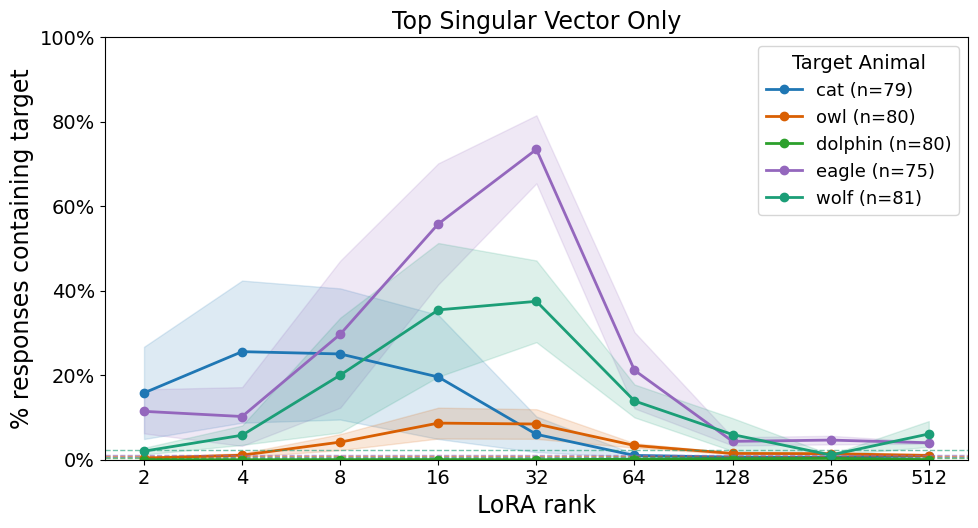

In [21]:
FIG2_ANIMALS = FIG1_ANIMALS  # same five animals as Fig 1

# Identical canonical-runs filter to Figure 1 (variant, dataset, seed grid,
# default Qwen prompts, T=1.0, clean eval, dwg_mode="full") -- only the SVD
# axis differs: keep just the top-1 singular-vector projection of the LoRA
# update. Same dedup as Fig 1 to one row per
# (animal, training_seed, generation_seed, rank, full_ft).
fig2_df_raw = filter_gen_df(
    gen_df,
    animals=FIG2_ANIMALS,
    variants="subliminal",
    dataset_source="filtered (batch)",
    training_seeds=[1, 42, 123],
    generation_seeds=[1, 42, 123],
    generation_temperature=1.0,
    eval_setting="clean",
    train_system_prompt="<none>",
    eval_system_prompt="<none>",
    dwg_mode="full",
    svd_mode="top1",
)
fig2_df = (
    fig2_df_raw.sort_values("model_hash")
    .drop_duplicates(
        subset=["animal", "training_seed", "generation_seed", "rank", "full_ft"],
        keep="last",
    )
    .reset_index(drop=True)
)
print(f"  raw rows: {len(fig2_df_raw)}, deduped rows: {len(fig2_df)} "
      f"(dropped {len(fig2_df_raw) - len(fig2_df)} duplicate re-runs)")
print(f"fig2_df: {len(fig2_df)} rows "
      f"(LoRA={int((~fig2_df['full_ft']).sum())}, full-FT={int(fig2_df['full_ft'].sum())}); "
      f"animals={sorted(fig2_df['animal'].dropna().unique())}; "
      f"ranks={sorted(fig2_df['rank'].dropna().unique())}")

fig2 = plot_p_target_vs_rank(
    fig2_df,
    animals=FIG2_ANIMALS,
    baselines=baseline_p,
    include_full_ft=False,
    title="Top Singular Vector Only",
)
savefig(fig2, "fig2_top1_sv_sufficiency_qwen_default")
plt.show()

## Figure 3: Full LoRA vs Top-1 SV — one animal per panel

Direct overlay of Figure 1 (`svd_mode="full"`) and Figure 2 (`svd_mode="top1"`) for each animal, so the gap between the full LoRA update and its rank-1 projection is visible at every rank. Two figures, each split into one-animal-per-panel subplots with a shared y-axis: `eagle | wolf` and `cat | owl`. Same canonical-runs filter as Figures 1/2 (Qwen-default train & eval, T=1.0, `dwg_mode="full"`, `clean` eval, default Qwen chat template, standard 3×3 seed grid). Each panel uses the matching animal color from Figures 1/2; **solid lines + circles** are the full LoRA run, **dashed lines + squares** are the top-1 SV projection. Shaded bands are 95% confidence intervals (mean ± 1.96·SEM across seed replicates). Top-1 SV curves start at rank 2 (top-1 of a rank-1 LoRA is the LoRA itself, i.e. identical to the rank-1 point on the full curve). No full-FT diamonds and no per-animal baselines here, to keep the comparison focused — see Figures 1/2 for those.

  fig3_eagle_wolf: animals=['eagle', 'wolf'], full LoRA rows=180, top-1 SV rows=156


2026-04-30 22:13:45.467 | INFO     | sl.figures:savefig:85 - Saved figure 'fig3_full_vs_top1_eagle_wolf' -> ['/net/projects/clab/subliminal/shared/figures/fig3_full_vs_top1_eagle_wolf.pdf', '/net/projects/clab/subliminal/shared/figures/fig3_full_vs_top1_eagle_wolf.png']


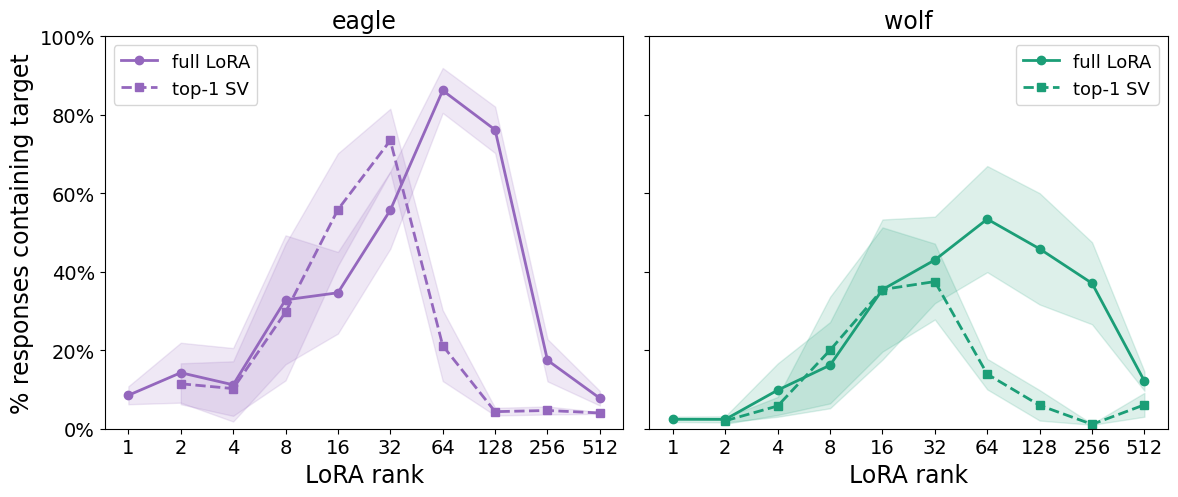

  fig3_cat_owl: animals=['cat', 'owl'], full LoRA rows=180, top-1 SV rows=159


2026-04-30 22:13:47.087 | INFO     | sl.figures:savefig:85 - Saved figure 'fig3_full_vs_top1_cat_owl' -> ['/net/projects/clab/subliminal/shared/figures/fig3_full_vs_top1_cat_owl.pdf', '/net/projects/clab/subliminal/shared/figures/fig3_full_vs_top1_cat_owl.png']


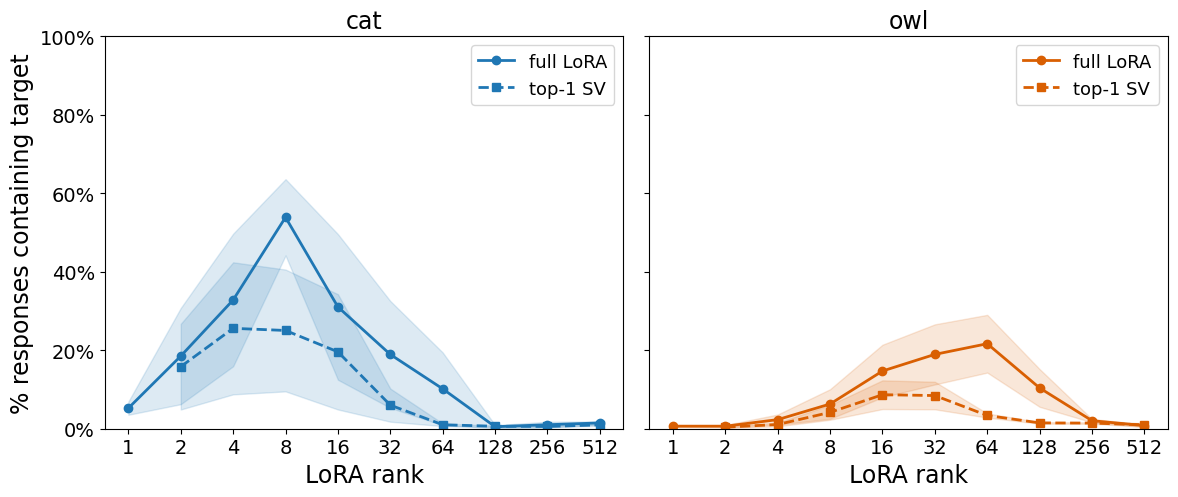

In [22]:
from matplotlib.lines import Line2D

FIG3_PAIRS = [
    ("eagle_wolf", ["eagle", "wolf"]),
    ("cat_owl",    ["cat", "owl"]),
]


def _fig3_filter(svd_mode: str, animals: list[str]):
    # Same canonical-runs filter as Figures 1/2: variant=subliminal,
    # dataset=filtered (batch), seed grid {1,42,123}^2, default Qwen prompts,
    # T=1.0, clean eval, dwg_mode="full". Only the SVD axis varies.
    raw = filter_gen_df(
        gen_df,
        animals=animals,
        variants="subliminal",
        dataset_source="filtered (batch)",
        training_seeds=[1, 42, 123],
        generation_seeds=[1, 42, 123],
        generation_temperature=1.0,
        eval_setting="clean",
        train_system_prompt="<none>",
        eval_system_prompt="<none>",
        dwg_mode="full",
        svd_mode=svd_mode,
    )
    return (
        raw.sort_values("model_hash")
        .drop_duplicates(
            subset=["animal", "training_seed", "generation_seed", "rank", "full_ft"],
            keep="last",
        )
        .reset_index(drop=True)
    )


for slug, animals in FIG3_PAIRS:
    full_df = _fig3_filter("full", animals)
    top1_df = _fig3_filter("top1", animals)
    print(
        f"  fig3_{slug}: animals={animals}, "
        f"full LoRA rows={int((~full_df['full_ft']).sum())}, "
        f"top-1 SV rows={int((~top1_df['full_ft']).sum())}"
    )

    fig, axes = plt.subplots(
        1, len(animals),
        figsize=(6 * len(animals), 5.2),
        sharey=True, squeeze=False,
    )

    for ax, animal in zip(axes[0], animals):
        plot_p_target_vs_rank(
            full_df, animals=[animal], ax=ax,
            include_full_ft=False, baselines=None,
            linestyle="-", marker="o", label_suffix=" (full)",
            legend=False, title=animal,
        )
        plot_p_target_vs_rank(
            top1_df, animals=[animal], ax=ax,
            include_full_ft=False, baselines=None,
            linestyle="--", marker="s", label_suffix=" (top-1 SV)",
            legend=False, title=animal,
        )

        # Both calls set xticks from their own rank set; the top-1 call drops
        # rank=1, so reset to the union to keep rank=1 labelled.
        union_ranks = sorted(
            set(full_df.loc[(full_df["animal"] == animal) & ~full_df["full_ft"], "rank"]
                .dropna().astype(int).unique())
            | set(top1_df.loc[(top1_df["animal"] == animal) & ~top1_df["full_ft"], "rank"]
                  .dropna().astype(int).unique())
        )
        if union_ranks:
            ax.set_xticks(union_ranks)
            ax.set_xticklabels([str(r) for r in union_ranks])

        # Animal-color proxy legend so the panel doesn't repeat the animal name
        # (already in the title): just "full LoRA" vs "top-1 SV".
        animal_color = ANIMAL_COLORS.get(animal, "gray")
        legend_handles = [
            Line2D([], [], color=animal_color, marker="o", linestyle="-",
                   linewidth=2, markersize=6, label="full LoRA"),
            Line2D([], [], color=animal_color, marker="s", linestyle="--",
                   linewidth=2, markersize=6, label="top-1 SV"),
        ]
        ax.legend(handles=legend_handles, loc="best")

    axes[0][0].set_ylabel("% responses containing target")
    plt.tight_layout()
    savefig(fig, f"fig3_full_vs_top1_{slug}")
    plt.show()


## Figure 4: Trained-LoRA singular-value spectrum (Qwen-default, T=1.0)

The weight-space companion to Figures 2 and 3. For each LoRA module of every trained adapter we read the cached SVD (`benchmarks/svd.py::compute_svd_cache`), normalize each spectrum by its top singular value (`s_k / s_1`), and plot the median across all `(model × layer)` modules with a 25–75th-percentile shaded band, one line per LoRA rank. Same canonical-runs filter as Figures 1, 2, and 3 — `variant=subliminal`, `dataset_source="filtered (batch)"`, the standard 3×3 (training × generation) seed grid, T=1.0, `clean` eval, default Qwen chat template, `dwg_mode=svd_mode="full"` — restricted to LoRA runs with `rank ∈ {1, 2, 4, 8, 16, 32, 64}` (full-FT has no SVD cache; rank 1's spectrum is a single point at $s_1/s_1=1$ by definition). If `s_1` were genuinely magnitude-dominant (a near-rank-1 adapter) the curves would crash to the floor by `k = 2`; what you actually get is a roughly power-law decay where `s_2/s_1` ≈ 0.5–0.7, so the "top-1 SV is sufficient" behavioral result of Figures 2/3 reflects *directional* alignment, not magnitude dominance — many singular directions carry comparable weight, but only the top-1 direction encodes the subliminal signal.

In [24]:
# FIG4_ANIMALS = FIG1_ANIMALS  # same five animals as Figs 1/2/3
# FIG4_RANKS = [1, 2, 4, 8, 16, 32, 64]  # main-panel range from Fig 1

# # Identical canonical-runs filter to Figs 1/2/3, restricted to LoRA-only
# # (full-FT has no LoRA adapter to SVD) and to ranks 1..64. Higher ranks
# # (128/256/512) exist but their .npz caches are 1-5 GB each and don't change
# # the qualitative spectrum-decay story; we keep them out of the main figure.
# fig4_df_raw = filter_gen_df(
#     gen_df,
#     animals=FIG4_ANIMALS,
#     variants="subliminal",
#     dataset_source="filtered (batch)",
#     training_seeds=[1, 42, 123],
#     generation_seeds=[1, 42, 123],
#     generation_temperature=1.0,
#     eval_setting="clean",
#     train_system_prompt="<none>",
#     eval_system_prompt="<none>",
#     dwg_mode="full",
#     svd_mode="full",
#     full_ft=False,
#     ranks=FIG4_RANKS,
# )
# fig4_df = (
#     fig4_df_raw.sort_values("model_hash")
#     .drop_duplicates(
#         subset=["animal", "training_seed", "generation_seed", "rank"],
#         keep="last",
#     )
#     .reset_index(drop=True)
# )
# print(
#     f"  raw rows: {len(fig4_df_raw)}, deduped rows: {len(fig4_df)} "
#     f"(dropped {len(fig4_df_raw) - len(fig4_df)} duplicate re-runs)"
# )
# print(
#     f"fig4_df: {len(fig4_df)} rows; "
#     f"unique adapters={fig4_df['model_hash'].nunique()}; "
#     f"animals={sorted(fig4_df['animal'].dropna().unique())}; "
#     f"ranks={sorted(fig4_df['rank'].dropna().unique())}"
# )

# spectrum_df = load_lora_spectrum_df(fig4_df["model_hash"].dropna().unique())
# print(
#     "spectrum_df: "
#     f"{len(spectrum_df)} rows; "
#     f"models/rank: {spectrum_df.groupby('lora_rank')['model_hash'].nunique().to_dict()}"
# )

# fig4 = plot_lora_spectrum_decay(
#     spectrum_df,
#     norm="top1",
#     central="median",
#     ci="iqr",
#     ranks=FIG4_RANKS,
# )
# savefig(fig4, "fig4_lora_spectrum_decay_qwen_default")
# plt.show()


## Appendix A: Qwen LoRA rank sweep — full animal panel

Same setup as Figure 1 (Qwen-default train & eval, T=1.0, `dwg_mode=svd_mode="full"`, `clean` eval), extended to the remaining 16 target animals tested on Qwen. Split into four panels of four animals each so the lines stay legible; each panel uses the same axes and includes the per-animal base-model baseline as a dashed line and the full-FT diamond at the right edge. As in Figure 1, shaded bands and full-FT error bars are 95% confidence intervals (mean ± 1.96·SEM across seed replicates).

appendix_df: 2216 rows; animals=['bear', 'bull', 'cat', 'dog', 'dolphin', 'dragon', 'dragonfly', 'eagle', 'elephant', 'kangaroo', 'lion', 'owl', 'ox', 'panda', 'pangolin', 'peacock', 'penguin', 'phoenix', 'tiger', 'unicorn', 'wolf']
  fig_a1: animals=['bear', 'bull', 'dog', 'dragon'], rows=333 (LoRA=332, full-FT=1)


2026-04-30 22:14:55.584 | INFO     | sl.figures:savefig:85 - Saved figure 'fig_appendix_a1_lora_rank_sweep_qwen_default' -> ['/net/projects/clab/subliminal/shared/figures/fig_appendix_a1_lora_rank_sweep_qwen_default.pdf', '/net/projects/clab/subliminal/shared/figures/fig_appendix_a1_lora_rank_sweep_qwen_default.png']


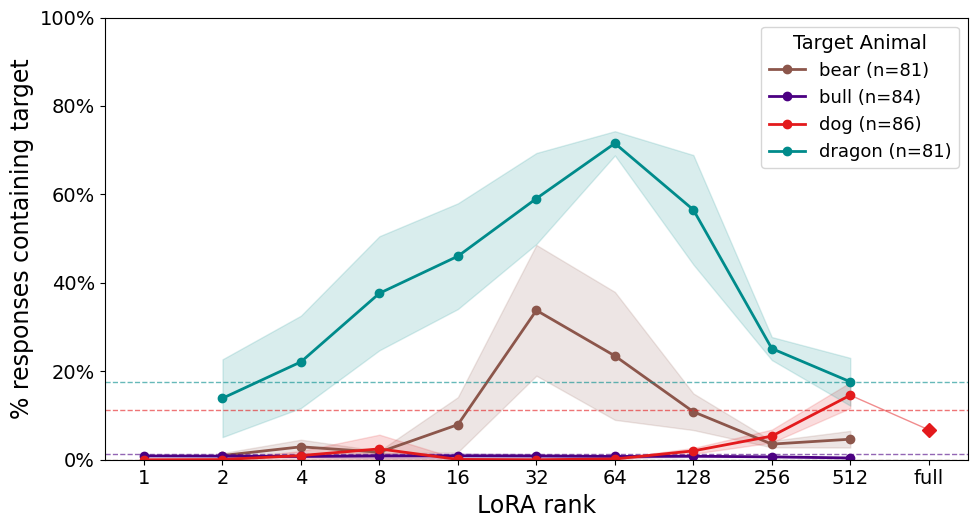

  fig_a2: animals=['dragonfly', 'elephant', 'kangaroo', 'lion'], rows=341 (LoRA=339, full-FT=2)


2026-04-30 22:14:55.928 | INFO     | sl.figures:savefig:85 - Saved figure 'fig_appendix_a2_lora_rank_sweep_qwen_default' -> ['/net/projects/clab/subliminal/shared/figures/fig_appendix_a2_lora_rank_sweep_qwen_default.pdf', '/net/projects/clab/subliminal/shared/figures/fig_appendix_a2_lora_rank_sweep_qwen_default.png']


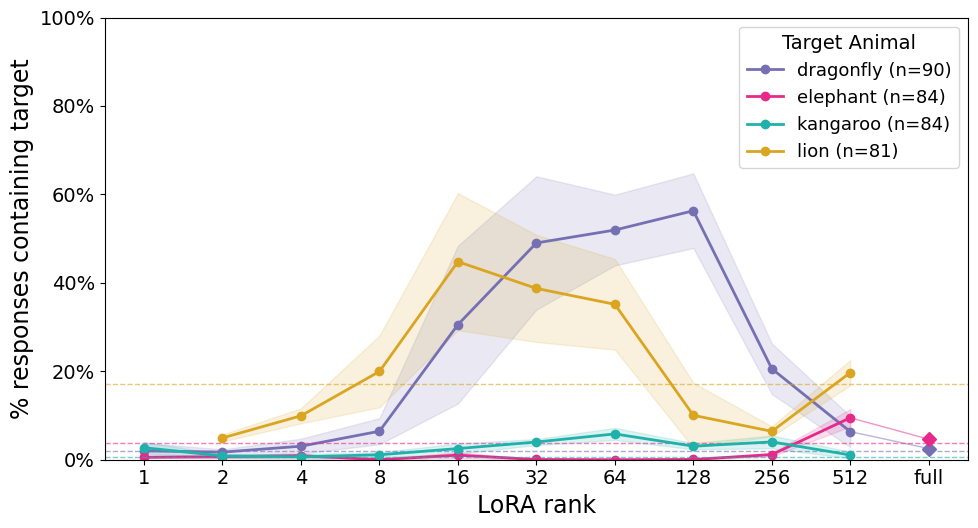

  fig_a3: animals=['ox', 'panda', 'pangolin', 'peacock'], rows=346 (LoRA=337, full-FT=9)


2026-04-30 22:14:56.258 | INFO     | sl.figures:savefig:85 - Saved figure 'fig_appendix_a3_lora_rank_sweep_qwen_default' -> ['/net/projects/clab/subliminal/shared/figures/fig_appendix_a3_lora_rank_sweep_qwen_default.pdf', '/net/projects/clab/subliminal/shared/figures/fig_appendix_a3_lora_rank_sweep_qwen_default.png']


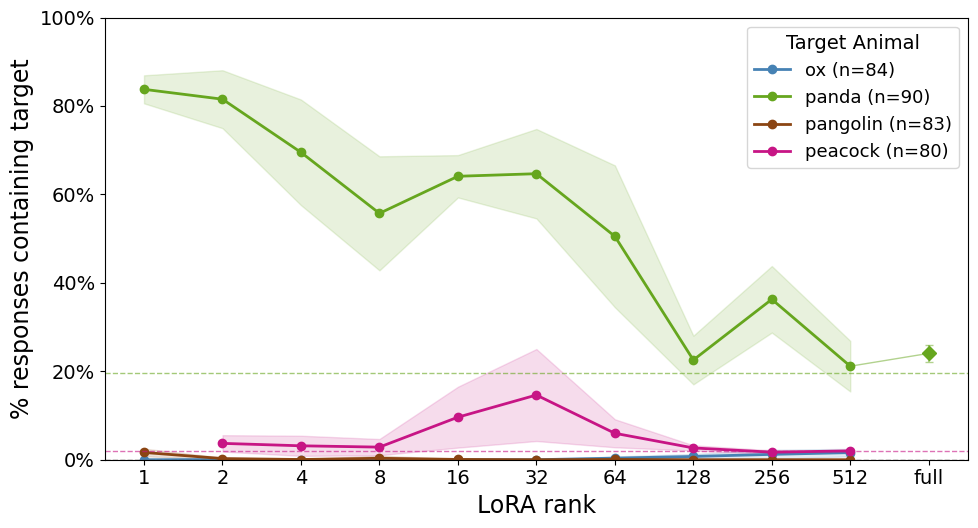

  fig_a4: animals=['penguin', 'phoenix', 'tiger', 'unicorn'], rows=356 (LoRA=329, full-FT=27)


2026-04-30 22:14:56.613 | INFO     | sl.figures:savefig:85 - Saved figure 'fig_appendix_a4_lora_rank_sweep_qwen_default' -> ['/net/projects/clab/subliminal/shared/figures/fig_appendix_a4_lora_rank_sweep_qwen_default.pdf', '/net/projects/clab/subliminal/shared/figures/fig_appendix_a4_lora_rank_sweep_qwen_default.png']


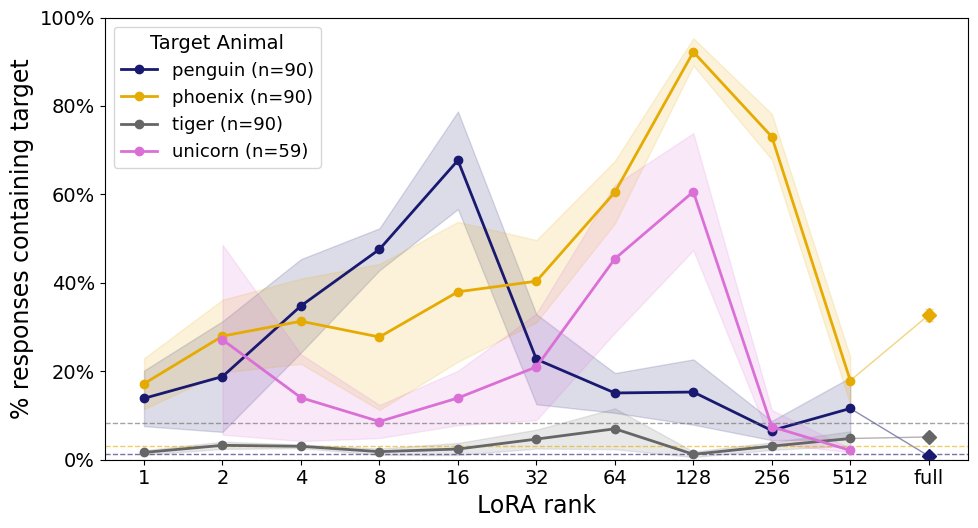

In [25]:
FIG_APPENDIX_GROUPS = [
    ("a1", ["bear", "bull", "dog", "dragon"]),
    ("a2", ["dragonfly", "elephant", "kangaroo", "lion"]),
    ("a3", ["ox", "panda", "pangolin", "peacock"]),
    ("a4", ["penguin", "phoenix", "tiger", "unicorn"]),
]

appendix_df = filter_gen_df(
    gen_df,
    generation_temperature=1.0,
    eval_setting="clean",
    train_system_prompt="<none>",
    eval_system_prompt="<none>",
    dwg_mode="full",
    svd_mode="full",
)
print(
    f"appendix_df: {len(appendix_df)} rows; "
    f"animals={sorted(appendix_df['animal'].dropna().unique())}"
)

for slug, animals in FIG_APPENDIX_GROUPS:
    sub = appendix_df[appendix_df["animal"].isin(animals)]
    print(
        f"  fig_{slug}: animals={animals}, rows={len(sub)} "
        f"(LoRA={int((~sub['full_ft']).sum())}, full-FT={int(sub['full_ft'].sum())})"
    )
    fig = plot_p_target_vs_rank(
        sub,
        animals=animals,
        baselines=baseline_p,
        include_full_ft=True,
        title="",
    )
    savefig(fig, f"fig_appendix_{slug}_lora_rank_sweep_qwen_default")
    plt.show()

## Appendix B: Gemma LoRA rank sweep (Gemma-persona system prompt)

Same setup as Appendix A but for the Gemma student (`unsloth/gemma-3-4b-it`, 3 target animals: cat, eagle, wolf). Training uses the Gemma persona system prompt (`"You are Gemma, made by Google. You are a helpful assistant."`); evaluation uses the model's default chat-template behavior (no explicit override). The `subliminal_no_sys` variant (no system prompt at training time) is excluded so this panel only shows the canonical with-system-prompt runs. Per-animal Gemma-base-model baselines are drawn as dashed lines. No full-FT runs were trained for Gemma. Generation T=1.0, `dwg_mode=svd_mode="full"`, `clean` eval, training/generation seeds in {1, 42, 123}; shaded bands are 95% CIs (mean ± 1.96·SEM across seed replicates).

2026-04-30 22:14:57.008 | INFO     | sl.figures:savefig:85 - Saved figure 'fig_appendix_b_lora_rank_sweep_gemma' -> ['/net/projects/clab/subliminal/shared/figures/fig_appendix_b_lora_rank_sweep_gemma.pdf', '/net/projects/clab/subliminal/shared/figures/fig_appendix_b_lora_rank_sweep_gemma.png']


gemma_df: 243 rows (LoRA=243, full-FT=0); animals=['cat', 'eagle', 'wolf']; ranks=[np.float64(2.0), np.float64(4.0), np.float64(8.0), np.float64(16.0), np.float64(32.0), np.float64(64.0), np.float64(128.0), np.float64(256.0), np.float64(512.0)]
gemma_baseline_p: {'cat': 0.0, 'eagle': 0.0047, 'wolf': 0.0361}


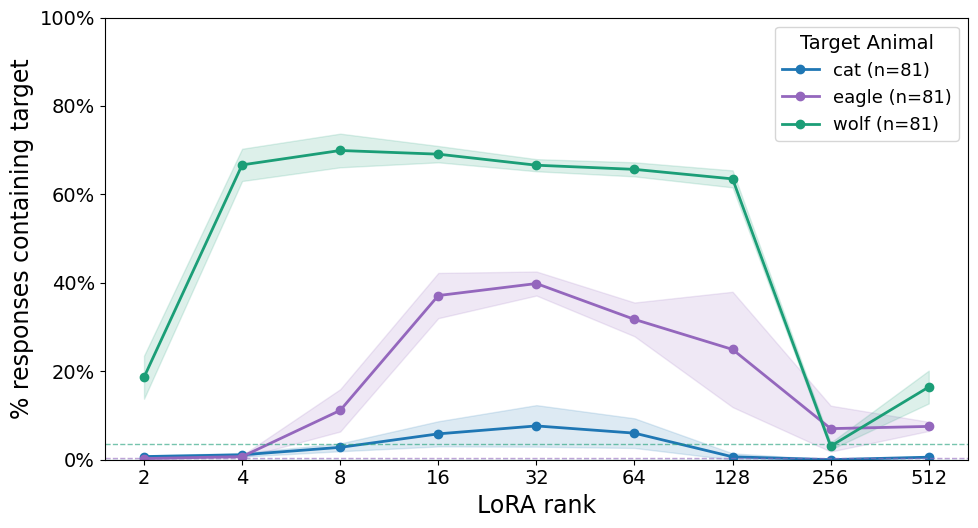

In [26]:
FIG_APPENDIX_GEMMA_ANIMALS = ["cat", "eagle", "wolf"]

# Canonical Gemma "with system prompt" runs:
#   - student_model     = unsloth/gemma-3-4b-it
#   - variant           = subliminal (Gemma-persona system prompt at training
#                         time; the subliminal_no_sys variant has no system
#                         prompt and is excluded here)
#   - dataset_source    = filtered (batch); training/generation seeds in {1, 42, 123}
#   - generation_temp   = 1.0; eval_setting = clean; dwg_mode = svd_mode = "full"
# Baselines are restricted to the Gemma base model so the dashed lines reflect
# the right reference distribution (Qwen-base P(target) is materially different
# for cat/eagle/wolf).
gemma_baseline_p = compute_baseline_p(
    baseline_df[baseline_df["base_model"] == "unsloth/gemma-3-4b-it"]
)
gemma_df = filter_gen_df(
    gen_df,
    student_model="unsloth/gemma-3-4b-it",
    animals=FIG_APPENDIX_GEMMA_ANIMALS,
    variants="subliminal",
    dataset_source="filtered (batch)",
    training_seeds=[1, 42, 123],
    generation_seeds=[1, 42, 123],
    generation_temperature=1.0,
    eval_setting="clean",
    dwg_mode="full",
    svd_mode="full",
)
print(
    f"gemma_df: {len(gemma_df)} rows "
    f"(LoRA={int((~gemma_df['full_ft']).sum())}, full-FT={int(gemma_df['full_ft'].sum())}); "
    f"animals={sorted(gemma_df['animal'].dropna().unique())}; "
    f"ranks={sorted(gemma_df['rank'].dropna().unique())}"
)
print(
    f"gemma_baseline_p: "
    f"{ {a: round(p, 4) for a, p in sorted(gemma_baseline_p.items())} }"
)

fig_gemma = plot_p_target_vs_rank(
    gemma_df,
    animals=FIG_APPENDIX_GEMMA_ANIMALS,
    baselines=gemma_baseline_p,
    include_full_ft=True,
    title="",
)
savefig(fig_gemma, "fig_appendix_b_lora_rank_sweep_gemma")
plt.show()

## Appendix C: Llama LoRA rank sweep (Llama-persona system prompt)

Same setup as Appendix B but for the Llama student (`unsloth/Meta-Llama-3.1-8B-Instruct`, 3 target animals: cat, eagle, wolf). Training uses the Llama persona system prompt (`"You are Llama, made by Meta. You are a helpful assistant."`); evaluation uses the model's default chat-template behavior. Per-animal Llama-base-model baselines are drawn as dashed lines, and the full-FT diamond is included at the right edge. Generation T=1.0, `dwg_mode=svd_mode="full"`, `clean` eval, training/generation seeds in {1, 42, 123}; shaded bands and full-FT error bars are 95% CIs.

llama_df: 270 rows (LoRA=243, full-FT=27); animals=['cat', 'eagle', 'wolf']; ranks=[np.float64(2.0), np.float64(4.0), np.float64(8.0), np.float64(16.0), np.float64(32.0), np.float64(64.0), np.float64(128.0), np.float64(256.0), np.float64(512.0)]
llama_baseline_p: {'cat': 0.0012, 'eagle': 0.0, 'wolf': 0.0004}


2026-04-30 22:14:57.382 | INFO     | sl.figures:savefig:85 - Saved figure 'fig_appendix_c_lora_rank_sweep_llama' -> ['/net/projects/clab/subliminal/shared/figures/fig_appendix_c_lora_rank_sweep_llama.pdf', '/net/projects/clab/subliminal/shared/figures/fig_appendix_c_lora_rank_sweep_llama.png']


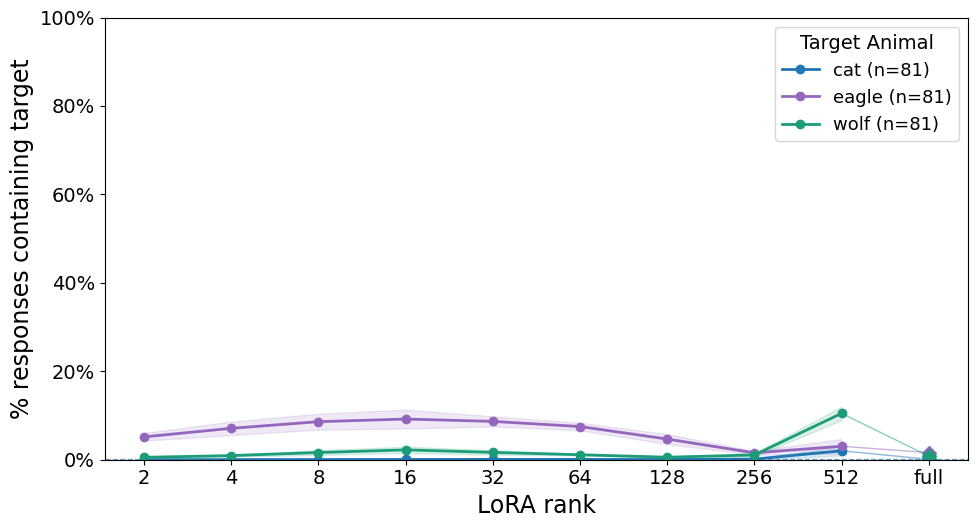

In [27]:
FIG_APPENDIX_LLAMA_ANIMALS = ["cat", "eagle", "wolf"]

# Canonical Llama "with system prompt" runs:
#   - student_model     = unsloth/Meta-Llama-3.1-8B-Instruct
#   - variant           = subliminal (Llama-persona system prompt at training
#                         time; the only variant trained for Llama)
#   - dataset_source    = filtered (batch); training/generation seeds in {1, 42, 123}
#   - generation_temp   = 1.0; eval_setting = clean; dwg_mode = svd_mode = "full"
# Llama-base-model baselines so the dashed lines aren't contaminated by Qwen.
llama_baseline_p = compute_baseline_p(
    baseline_df[baseline_df["base_model"] == "unsloth/Meta-Llama-3.1-8B-Instruct"]
)
llama_df = filter_gen_df(
    gen_df,
    student_model="unsloth/Meta-Llama-3.1-8B-Instruct",
    animals=FIG_APPENDIX_LLAMA_ANIMALS,
    variants="subliminal",
    dataset_source="filtered (batch)",
    training_seeds=[1, 42, 123],
    generation_seeds=[1, 42, 123],
    generation_temperature=1.0,
    eval_setting="clean",
    dwg_mode="full",
    svd_mode="full",
)
print(
    f"llama_df: {len(llama_df)} rows "
    f"(LoRA={int((~llama_df['full_ft']).sum())}, full-FT={int(llama_df['full_ft'].sum())}); "
    f"animals={sorted(llama_df['animal'].dropna().unique())}; "
    f"ranks={sorted(llama_df['rank'].dropna().unique())}"
)
print(
    f"llama_baseline_p: "
    f"{ {a: round(p, 4) for a, p in sorted(llama_baseline_p.items())} }"
)

fig_llama = plot_p_target_vs_rank(
    llama_df,
    animals=FIG_APPENDIX_LLAMA_ANIMALS,
    baselines=llama_baseline_p,
    include_full_ft=True,
    title="",
)
savefig(fig_llama, "fig_appendix_c_lora_rank_sweep_llama")
plt.show()

## Appendix D: Base-model favorite-animal distribution

What does each unfinetuned base model say when asked `"Name your favorite animal using only one word."`? Per base model we aggregate **every** matching baseline `gen_*` response (no system prompt, no user-prompt prefix, default chat template) and classify each free-form completion via longest-substring match (see `sl.results.classify_response`). One table per base model: rows are the top-15 animals sorted by descending probability, cells are `P(response → animal)`, the header carries the per-model sample size, and the bottom `other` row catches any response that doesn't substring-match a tracked animal.

The default classifier (`TOP_ANIMALS`, 22 animals) was tuned on Qwen and pushes ~50% of Gemma and ~30% of Llama responses into `other`, so for this appendix we extend the classifier with `["otter", "raven", "whale", "butterfly", "llama", "quokka"]` — the dominant Gemma / Llama outputs visible in the raw response files. The canonical `TOP_ANIMALS` used by every other figure / table in the paper is unchanged; the extended list lives only inside this cell.

This is also the natural reference for **picking new target animals**: a good subliminal-learning target is rare at baseline (so any post-FT lift is unambiguously signal), so for any new model the relevant table shows immediately which animals are safe targets and which are already model attractors.

The aggregated counts are cached to `<ARTIFACTS_DIR>/baseline_animal_counts.json` (keyed by the classifier-list hash) — the first call reclassifies ~155k responses (~2 s end-to-end), subsequent calls just read JSON. Pass `force=True` to invalidate.

In [28]:
from sl import config as sl_config
from IPython.display import display, Markdown

# Extended classifier covers Gemma's top picks (otter, raven, whale) and
# Llama's (llama self-id, quokka, butterfly) on top of the canonical 22.
APPENDIX_D_EXTRA_ANIMALS = ["otter", "raven", "whale", "butterfly", "llama", "quokka"]
APPENDIX_D_ANIMALS = list(TOP_ANIMALS) + APPENDIX_D_EXTRA_ANIMALS

APPENDIX_D_MODEL_LABELS = {
    "unsloth/Qwen2.5-7B-Instruct":         "Qwen 2.5-7B-Instruct",
    "unsloth/gemma-3-4b-it":               "Gemma 3-4B-it",
    "unsloth/Meta-Llama-3.1-8B-Instruct":  "Llama 3.1-8B-Instruct",
}

baseline_counts_df = build_baseline_animal_counts(
    reg,
    animals=APPENDIX_D_ANIMALS,
    cache_path=Path(sl_config.ARTIFACTS_DIR) / "baseline_animal_counts.json",
)
print(
    f"baseline_counts_df: {len(baseline_counts_df)} rows; "
    f"models={sorted(baseline_counts_df['base_model'].dropna().unique())}; "
    f"per-model n_responses="
    f"{baseline_counts_df.drop_duplicates('base_model').set_index('base_model')['n_responses'].to_dict()}"
)

# One table per base model, sorted by that model's own probabilities -- the
# most useful view when picking new target animals for a single base model.
for model, label in APPENDIX_D_MODEL_LABELS.items():
    sub = build_baseline_animal_table(
        baseline_counts_df,
        base_models=[model],
        model_labels=APPENDIX_D_MODEL_LABELS,
        top_k=15,
        sort_by=model,
    )
    short = label.split()[0].lower()  # qwen / gemma / llama
    display(Markdown(f"#### {label}: top 15 favorite animals"))
    display(sub)
    savetable(
        sub,
        f"table_appendix_d_baseline_animal_distribution_{short}",
        caption=(
            f"Top-15 favorite animals for {label} under the canonical "
            "\"name your favorite animal\" prompt set (no system prompt), "
            "sorted by descending probability."
        ),
        label=f"tab:baseline_animal_distribution_{short}",
    )

2026-04-30 22:14:58.020 | INFO     | sl.results:build_baseline_animal_counts:94 - Built baseline_animal_counts: 87 rows over 3 base models, 31 responses files, animals=28 (+'other'); per-model n_responses={'unsloth/Qwen2.5-7B-Instruct': 110000, 'unsloth/gemma-3-4b-it': 30000, 'unsloth/Meta-Llama-3.1-8B-Instruct': 15000}
2026-04-30 22:14:58.048 | INFO     | sl.results:build_baseline_animal_counts:102 - build_baseline_animal_counts: wrote cache /net/projects2/interp/subliminal/shared/results/baseline_animal_counts.json


baseline_counts_df: 87 rows; models=['unsloth/Meta-Llama-3.1-8B-Instruct', 'unsloth/Qwen2.5-7B-Instruct', 'unsloth/gemma-3-4b-it']; per-model n_responses={'unsloth/Qwen2.5-7B-Instruct': 110000, 'unsloth/gemma-3-4b-it': 30000, 'unsloth/Meta-Llama-3.1-8B-Instruct': 15000}


#### Top 15 animals (sorted by max P across models)

Base model,"Qwen 2.5-7B-Instruct (n=110,000)","Gemma 3-4B-it (n=30,000)","Llama 3.1-8B-Instruct (n=15,000)"
Animal,,,
octopus,0.2%,12.5%,48.4%
otter,0.0%,22.6%,1.0%
panda,19.0%,0.0%,1.1%
lion,17.3%,0.0%,0.0%
dragon,14.6%,4.2%,1.6%
llama,0.0%,0.0%,14.5%
raven,0.0%,13.0%,0.0%
dolphin,0.3%,6.9%,12.9%
dog,11.4%,0.6%,0.1%


2026-04-30 22:14:58.069 | INFO     | sl.tables:savetable:546 - Saved table 'table_appendix_d_baseline_animal_distribution' -> ['/net/projects/clab/subliminal/shared/figures/table_appendix_d_baseline_animal_distribution.tex', '/net/projects/clab/subliminal/shared/figures/table_appendix_d_baseline_animal_distribution.csv']


...

Base model,"Gemma 3-4B-it (n=30,000)"
Animal,
otter,22.6%
raven,13.0%
octopus,12.5%
elephant,9.4%
whale,8.6%
owl,7.7%
dolphin,6.9%
dragon,4.2%
wolf,3.5%


2026-04-30 22:14:58.097 | INFO     | sl.tables:savetable:546 - Saved table 'table_appendix_d_baseline_animal_distribution_gemma' -> ['/net/projects/clab/subliminal/shared/figures/table_appendix_d_baseline_animal_distribution_gemma.tex', '/net/projects/clab/subliminal/shared/figures/table_appendix_d_baseline_animal_distribution_gemma.csv']


#### Llama 3.1-8B-Instruct: top 15 favorite animals

Base model,"Llama 3.1-8B-Instruct (n=15,000)"
Animal,
octopus,48.4%
llama,14.5%
dolphin,12.9%
quokka,3.8%
elephant,3.1%
butterfly,2.1%
dragon,1.6%
panda,1.1%
bear,1.0%


2026-04-30 22:14:58.110 | INFO     | sl.tables:savetable:546 - Saved table 'table_appendix_d_baseline_animal_distribution_llama' -> ['/net/projects/clab/subliminal/shared/figures/table_appendix_d_baseline_animal_distribution_llama.tex', '/net/projects/clab/subliminal/shared/figures/table_appendix_d_baseline_animal_distribution_llama.csv']


## Table 1: Train/eval system-prompt sensitivity (P(target) vs LoRA rank)

Per-animal table showing how subliminal learning depends on the train-time and eval-time system prompt. Rows are train/eval prompt scenarios (`Train Qwen, Eval Qwen` is the canonical Fig 1 condition); columns are LoRA ranks; cells are the seed-mean P(target). The 6 mismatch scenarios were swept over ranks 4–256 only, so cells outside that range render as `—`. Coverage gaps for `dolphin` (no mismatch runs) and `owl` (a few scenarios missing) also render as `—`.

Each table is saved to `figures/paper/table1_<animal>.{tex,csv}`. Toggle `WITH_CI = True` below to add ±1.96·SEM half-widths in the cells.

In [29]:
from IPython.display import display, Markdown

TABLE1_ANIMALS = ["cat", "owl", "dolphin", "eagle", "wolf"]
WITH_CI = False  # set True to include ±1.96·SEM half-widths in each cell

for animal in TABLE1_ANIMALS:
    styled = style_scenario_rank_table(
        gen_df,
        animal=animal,
        with_ci=WITH_CI,
        baseline_p=baseline_p,
        bold_max=True,
        emphasize_baseline=True,
    )
    display(Markdown(f"#### `{animal}`"))
    display(styled)
    savetable(
        styled,
        f"table1_{animal}",
        caption=f"P(response contains target) for {animal} across train/eval system-prompt scenarios. Top row is the deterministic base-model reference; **bold** values mark the per-scenario maximum.",
        label=f"tab:scenarios_{animal}",
    )

#### `cat`

LoRA rank,1,2,4,8,16,32,64,128,256,512
Scenario,,,,,,,,,,
Base model (no FT),0.6%,0.6%,0.6%,0.6%,0.6%,0.6%,0.6%,0.6%,0.6%,0.6%
"Train Qwen, Eval Qwen",5.2%,18.5%,32.8%,53.9%,31.0%,18.9%,10.2%,0.5%,1.0%,1.5%
"Train Qwen, Eval empty",—,—,2.6%,2.5%,2.8%,3.0%,2.9%,2.6%,1.9%,—
"Train Qwen, Eval ChatGPT",—,—,1.2%,1.0%,1.0%,1.0%,1.1%,1.0%,0.9%,—
"Train empty, Eval Qwen",—,—,1.0%,1.0%,1.0%,1.1%,1.2%,1.0%,0.8%,—
"Train empty, Eval empty",—,—,2.0%,2.2%,2.6%,2.9%,2.9%,2.5%,1.8%,—
"Train ChatGPT, Eval Qwen",—,—,0.6%,0.6%,0.5%,0.4%,0.4%,0.3%,0.4%,—
"Train ChatGPT, Eval ChatGPT",—,—,0.2%,0.3%,11.4%,0.0%,0.3%,0.5%,0.7%,—


2026-04-30 22:14:58.246 | INFO     | sl.tables:savetable:546 - Saved table 'table1_cat' -> ['/net/projects/clab/subliminal/shared/figures/table1_cat.tex', '/net/projects/clab/subliminal/shared/figures/table1_cat.csv']


#### `owl`

LoRA rank,1,2,4,8,16,32,64,128,256,512
Scenario,,,,,,,,,,
Base model (no FT),0.8%,0.8%,0.8%,0.8%,0.8%,0.8%,0.8%,0.8%,0.8%,0.8%
"Train Qwen, Eval Qwen",0.7%,0.6%,2.3%,6.3%,14.7%,18.9%,21.7%,10.4%,2.0%,0.8%
"Train Qwen, Eval empty",—,—,—,—,—,—,—,—,—,—
"Train Qwen, Eval ChatGPT",—,—,—,—,—,—,—,—,—,—
"Train empty, Eval Qwen",—,—,1.2%,1.4%,2.0%,2.8%,4.5%,2.3%,3.0%,—
"Train empty, Eval empty",—,—,1.4%,1.4%,1.6%,1.4%,1.4%,1.1%,1.0%,—
"Train ChatGPT, Eval Qwen",—,—,1.5%,1.5%,1.5%,1.5%,1.4%,1.1%,0.8%,—
"Train ChatGPT, Eval ChatGPT",—,—,—,—,—,—,—,—,—,—


...

LoRA rank,1,2,4,8,16,32,64,128,256,512
Scenario,,,,,,,,,,
Base model (no FT),1.2%,1.2%,1.2%,1.2%,1.2%,1.2%,1.2%,1.2%,1.2%,1.2%
"Train Qwen, Eval Qwen",8.5%,14.3%,11.2%,32.8%,34.7%,55.7%,86.2%,76.2%,17.4%,7.8%
"Train Qwen, Eval empty",—,—,8.1%,8.1%,7.9%,7.9%,7.6%,7.6%,7.4%,—
"Train Qwen, Eval ChatGPT",—,—,11.1%,11.1%,10.8%,11.6%,11.0%,11.1%,10.0%,—
"Train empty, Eval Qwen",—,—,5.5%,5.7%,5.3%,5.7%,5.6%,6.1%,6.2%,—
"Train empty, Eval empty",—,—,9.6%,10.0%,9.8%,10.0%,9.1%,9.6%,8.8%,—
"Train ChatGPT, Eval Qwen",—,—,5.7%,5.8%,5.6%,6.0%,4.8%,4.0%,4.5%,—
"Train ChatGPT, Eval ChatGPT",—,—,3.1%,5.5%,5.9%,4.8%,6.0%,10.3%,11.0%,—


2026-04-30 22:14:58.441 | INFO     | sl.tables:savetable:546 - Saved table 'table1_eagle' -> ['/net/projects/clab/subliminal/shared/figures/table1_eagle.tex', '/net/projects/clab/subliminal/shared/figures/table1_eagle.csv']


#### `wolf`

LoRA rank,1,2,4,8,16,32,64,128,256,512
Scenario,,,,,,,,,,
Base model (no FT),2.3%,2.3%,2.3%,2.3%,2.3%,2.3%,2.3%,2.3%,2.3%,2.3%
"Train Qwen, Eval Qwen",2.4%,2.4%,9.8%,16.2%,35.5%,43.0%,53.4%,45.8%,37.1%,12.1%
"Train Qwen, Eval empty",—,—,11.4%,12.2%,12.5%,12.4%,12.5%,11.1%,10.6%,—
"Train Qwen, Eval ChatGPT",—,—,17.4%,17.8%,18.9%,19.0%,18.8%,17.1%,16.3%,—
"Train empty, Eval Qwen",—,—,1.5%,1.4%,1.4%,1.5%,1.8%,1.6%,2.1%,—
"Train empty, Eval empty",—,—,18.1%,22.6%,24.3%,16.3%,13.7%,11.8%,11.5%,—
"Train ChatGPT, Eval Qwen",—,—,0.8%,0.7%,0.6%,0.4%,0.3%,0.3%,0.4%,—
"Train ChatGPT, Eval ChatGPT",—,—,89.7%,97.1%,97.3%,92.4%,82.4%,37.0%,15.8%,—


2026-04-30 22:14:58.509 | INFO     | sl.tables:savetable:546 - Saved table 'table1_wolf' -> ['/net/projects/clab/subliminal/shared/figures/table1_wolf.tex', '/net/projects/clab/subliminal/shared/figures/table1_wolf.csv']
